In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
df = pd.read_csv("Groceries_dataset.csv")

In [5]:
df.shape

(38765, 3)

In [6]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [8]:
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


In [9]:
df.dtypes

,0
Member_number,int64
Date,object
itemDescription,object


In [10]:
df["Date"] = pd.to_datetime(df["Date"])

/tmp/ipykernel_535/936118274.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [11]:
total_rows = df.shape[0]
total_columns = df.shape[1]
unique_customers = df["Member_number"].nunique()
unique_products = df["itemDescription"].nunique()

df["BasketID"] = (
    df["Member_number"].astype(str)
    + "_"
    + df["Date"].astype(str)
)

unique_baskets = df["BasketID"].nunique()

overview_df = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Unique Customers",
        "Unique Products",
        "Unique Baskets"
    ],
    "Value": [
        total_rows,
        total_columns,
        unique_customers,
        unique_products,
        unique_baskets
    ]
})

print("\nDataset Overview:")
print(overview_df)


Dataset Overview:
             Metric  Value
0        Total Rows  38765
1     Total Columns      3
2  Unique Customers   3898
3   Unique Products    167
4    Unique Baskets  14963


In [12]:
basket_df = (
    df.groupby(
        ["BasketID", "Member_number", "Date"]
    )["itemDescription"]
    .count()
    .reset_index()
)

basket_df.rename(
    columns={"itemDescription": "BasketSize"},
    inplace=True
)

print("\nBasket DataFrame:")
print(basket_df.head())


Basket DataFrame:
          BasketID  Member_number       Date  BasketSize
0  1000_2014-06-24           1000 2014-06-24           3
1  1000_2015-03-15           1000 2015-03-15           4
2  1000_2015-05-27           1000 2015-05-27           2
3  1000_2015-07-24           1000 2015-07-24           2
4  1000_2015-11-25           1000 2015-11-25           2


In [13]:
average_basket_size = basket_df["BasketSize"].mean()
maximum_basket_size = basket_df["BasketSize"].max()

basket_distribution = (
    basket_df["BasketSize"]
    .value_counts()
    .sort_index()
    .reset_index()
)

basket_distribution.columns = [
    "Basket Size",
    "Number of Baskets"
]

print("\nAverage Basket Size:")
print(round(average_basket_size, 2))

print("\nMaximum Basket Size:")
print(maximum_basket_size)

print("\nBasket Size Distribution:")
print(basket_distribution)


Average Basket Size:
2.59

Maximum Basket Size:
11

Basket Size Distribution:
   Basket Size  Number of Baskets
0            2              10080
1            3               2698
2            4               1390
3            5                344
4            6                175
5            7                 80
6            8                145
7            9                 50
8           11                  1


In [14]:
purchase_frequency = (
    df.groupby("Member_number")["Date"]
    .nunique()
    .reset_index()
)

purchase_frequency.columns = [
    "Member_number",
    "PurchaseFrequency"
]

purchase_frequency["FrequencySegment"] = pd.cut(
    purchase_frequency["PurchaseFrequency"],
    bins=[0, 1, 5, 10, 100],
    labels=[
        "1 Visit",
        "2–5 Visits",
        "6–10 Visits",
        "10+ Visits"
    ]
)

frequency_segment_summary = (
    purchase_frequency["FrequencySegment"]
    .value_counts()
    .reset_index()
)

frequency_segment_summary.columns = [
    "Frequency Segment",
    "Customer Count"
]

print("\nPurchase Frequency:")
print(purchase_frequency.head())

print("\nFrequency Segment Summary:")
print(frequency_segment_summary)


Purchase Frequency:
   Member_number  PurchaseFrequency FrequencySegment
0           1000                  5       2–5 Visits
1           1001                  5       2–5 Visits
2           1002                  4       2–5 Visits
3           1003                  4       2–5 Visits
4           1004                  8      6–10 Visits

Frequency Segment Summary:
  Frequency Segment  Customer Count
0        2–5 Visits            2819
1       6–10 Visits             725
2           1 Visit             349
3        10+ Visits               5


In [15]:
top_products = (
    df["itemDescription"]
    .value_counts()
    .reset_index()
)

top_products.columns = [
    "Product",
    "PurchaseCount"
]

top_20_products = top_products.head(20)

print("\nTop 20 Products:")
print(top_20_products)


Top 20 Products:
               Product  PurchaseCount
0           whole milk           2502
1     other vegetables           1898
2           rolls/buns           1716
3                 soda           1514
4               yogurt           1334
5      root vegetables           1071
6       tropical fruit           1032
7        bottled water            933
8              sausage            924
9         citrus fruit            812
10              pastry            785
11           pip fruit            744
12       shopping bags            731
13         canned beer            717
14        bottled beer            687
15  whipped/sour cream            662
16          newspapers            596
17         frankfurter            580
18         brown bread            571
19                pork            566


In [16]:
df["Weekday"] = df["Date"].dt.day_name()

weekday_transactions = (
    basket_df.merge(
        df[["BasketID", "Weekday"]].drop_duplicates(),
        on="BasketID"
    )
)

transaction_count_weekday = (
    weekday_transactions["Weekday"]
    .value_counts()
    .reset_index()
)

transaction_count_weekday.columns = [
    "Weekday",
    "TransactionCount"
]

average_basket_weekday = (
    weekday_transactions.groupby("Weekday")["BasketSize"]
    .mean()
    .reset_index()
)

average_basket_weekday.columns = [
    "Weekday",
    "AverageBasketSize"
]

weekday_summary = transaction_count_weekday.merge(
    average_basket_weekday,
    on="Weekday"
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary["Weekday"] = pd.Categorical(
    weekday_summary["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_summary = weekday_summary.sort_values("Weekday")

print("\nWeekday Summary:")
print(weekday_summary)


Weekday Summary:
     Weekday  TransactionCount  AverageBasketSize
6     Monday              2067           2.603774
2    Tuesday              2142           2.594771
5  Wednesday              2131           2.610042
0   Thursday              2188           2.568556
4     Friday              2136           2.603933
1   Saturday              2161           2.568718
3     Sunday              2138           2.586529


In [17]:
basket_products = (
    df.groupby("BasketID")["itemDescription"]
    .apply(list)
)

pair_list = []

for products in basket_products:
    unique_products_list = sorted(list(set(products)))

    for i in range(len(unique_products_list)):
        for j in range(i + 1, len(unique_products_list)):
            pair_list.append(
                (
                    unique_products_list[i],
                    unique_products_list[j]
                )
            )

pair_df = pd.DataFrame(pair_list, columns=["Product1", "Product2"])

co_occurrence = (
    pair_df.value_counts()
    .reset_index(name="Count")
)

top_co_occurrence = co_occurrence.head(20)

print("\nTop Product Co-Occurrence:")
print(top_co_occurrence)


Top Product Co-Occurrence:
            Product1        Product2  Count
0   other vegetables      whole milk    222
1         rolls/buns      whole milk    209
2               soda      whole milk    174
3         whole milk          yogurt    167
4   other vegetables      rolls/buns    158
5   other vegetables            soda    145
6            sausage      whole milk    134
7     tropical fruit      whole milk    123
8   other vegetables          yogurt    121
9         rolls/buns            soda    121
10        rolls/buns          yogurt    117
11   root vegetables      whole milk    113
12      citrus fruit      whole milk    107
13     bottled water      whole milk    107
14      bottled beer      whole milk    107
15         pip fruit      whole milk     99
16            pastry      whole milk     97
17     shopping bags      whole milk     95
18  other vegetables  tropical fruit     94
19        rolls/buns  tropical fruit     91


In [18]:
top_customers = (
    basket_df.groupby("Member_number")["BasketID"]
    .count()
    .reset_index()
)

top_customers.columns = [
    "Member_number",
    "BasketCount"
]

top_customers = top_customers.sort_values(
    by="BasketCount",
    ascending=False
).head(10)

customer_monthly = (
    basket_df[
        basket_df["Member_number"].isin(
            top_customers["Member_number"]
        )
    ]
    .copy()
)

customer_monthly["YearMonth"] = (
    customer_monthly["Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_frequency = (
    customer_monthly.groupby(
        ["YearMonth", "Member_number"]
    )["BasketID"]
    .count()
    .reset_index()
)

monthly_frequency.columns = [
    "YearMonth",
    "Member_number",
    "MonthlyBasketCount"
]

print("\nTop Customers:")
print(top_customers)

print("\nMonthly Shopping Frequency:")
print(monthly_frequency.head())



Top Customers:
      Member_number  BasketCount
1234           2271           11
3250           4338           11
2665           3737           11
369            1379           11
1159           2193           11
3286           4376           10
3763           4864           10
400            1410           10
2415           3484           10
3132           4217           10

Monthly Shopping Frequency:
  YearMonth  Member_number  MonthlyBasketCount
0   2014-01           1410                   1
1   2014-01           2193                   1
2   2014-01           3737                   1
3   2014-02           1379                   1
4   2014-02           1410                   2


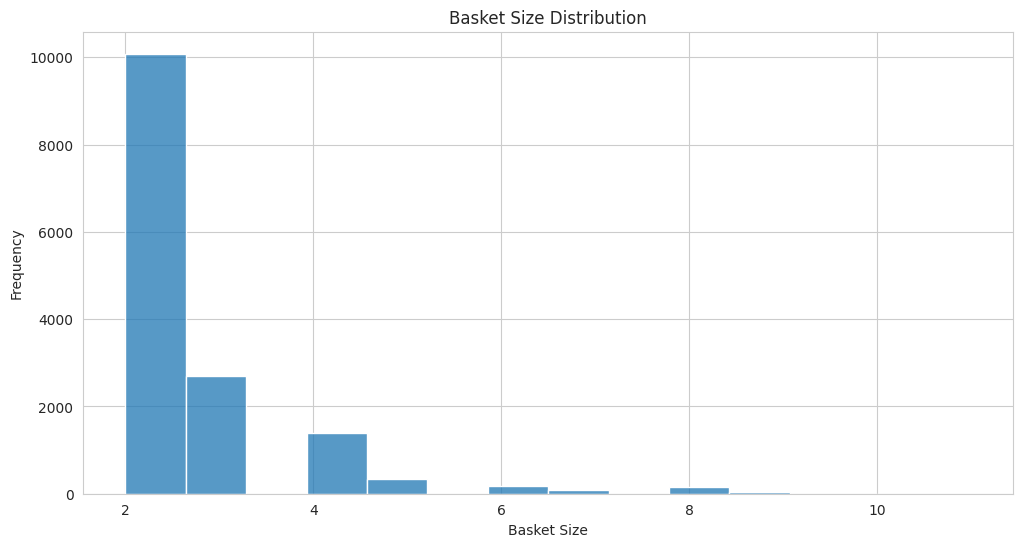

In [22]:
sns.histplot(
    basket_df["BasketSize"],
    bins=14,
    kde=False
)

plt.title("Basket Size Distribution")
plt.xlabel("Basket Size")
plt.ylabel("Frequency")

plt.show()

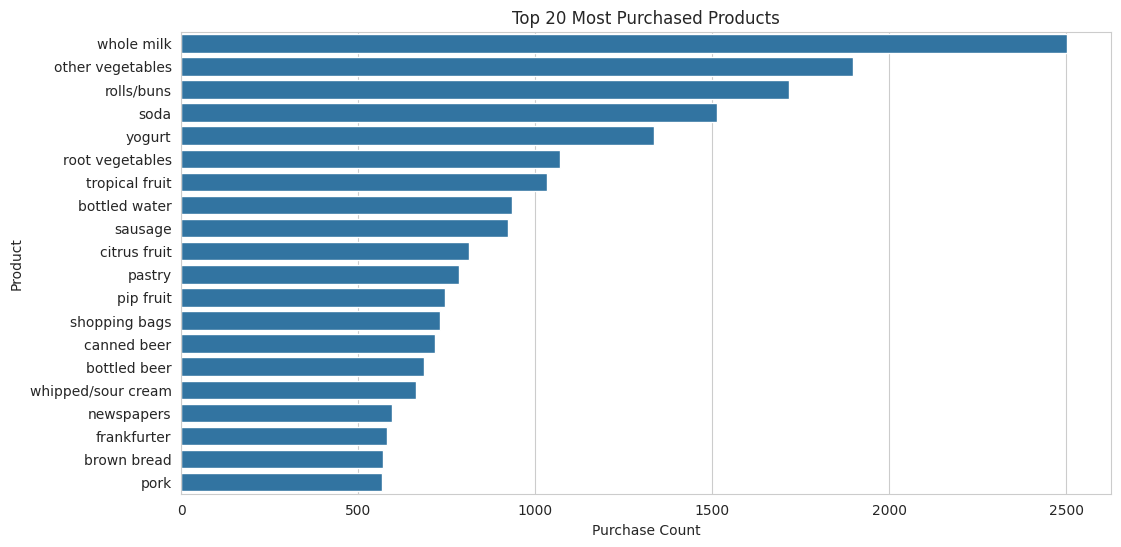

In [21]:
sns.barplot(
    data=top_20_products,
    x="PurchaseCount",
    y="Product"
)

plt.title("Top 20 Most Purchased Products")
plt.xlabel("Purchase Count")
plt.ylabel("Product")

plt.show()

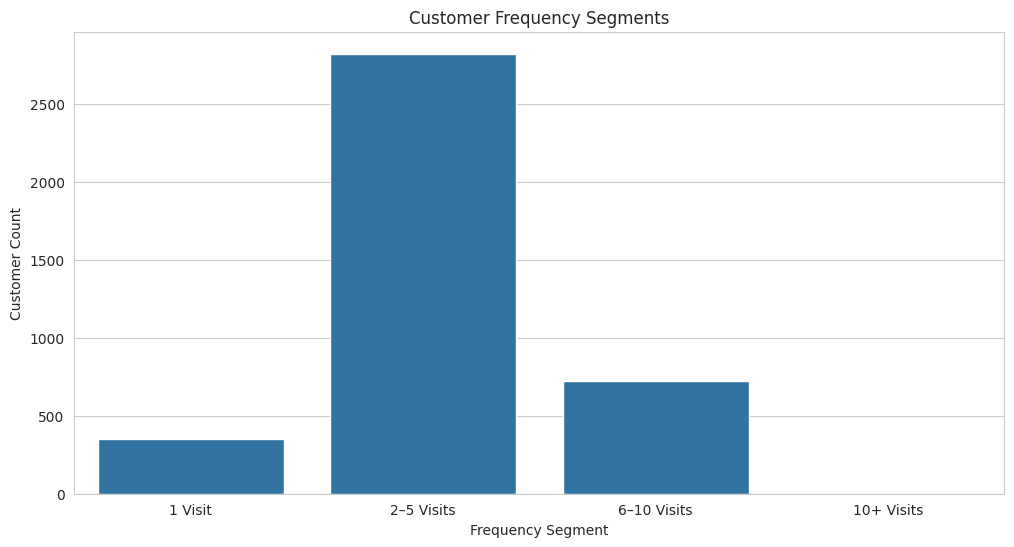

In [23]:
sns.barplot(
    data=frequency_segment_summary,
    x="Frequency Segment",
    y="Customer Count"
)

plt.title("Customer Frequency Segments")
plt.xlabel("Frequency Segment")
plt.ylabel("Customer Count")

plt.show()

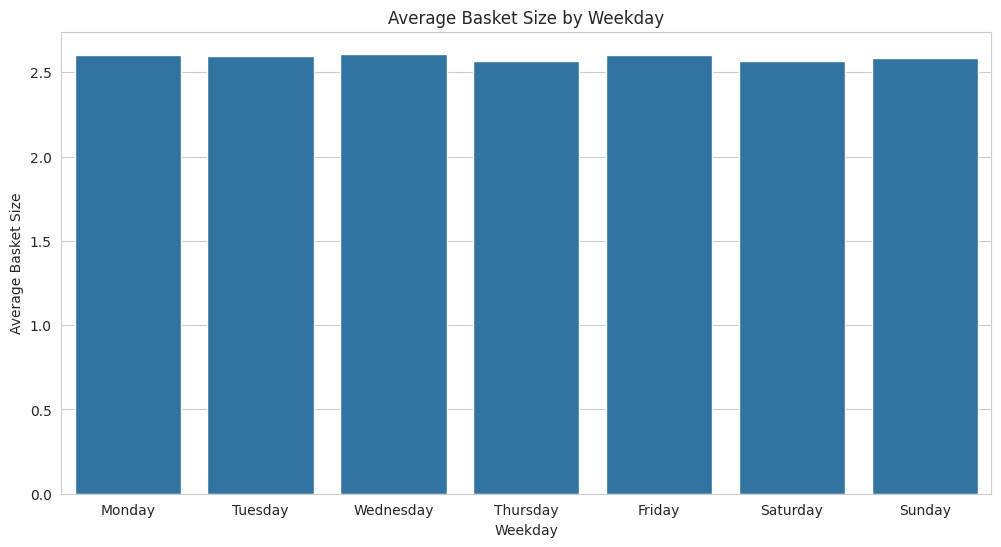

In [24]:
sns.barplot(
    data=weekday_summary,
    x="Weekday",
    y="AverageBasketSize"
)

plt.title("Average Basket Size by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Basket Size")

plt.show()

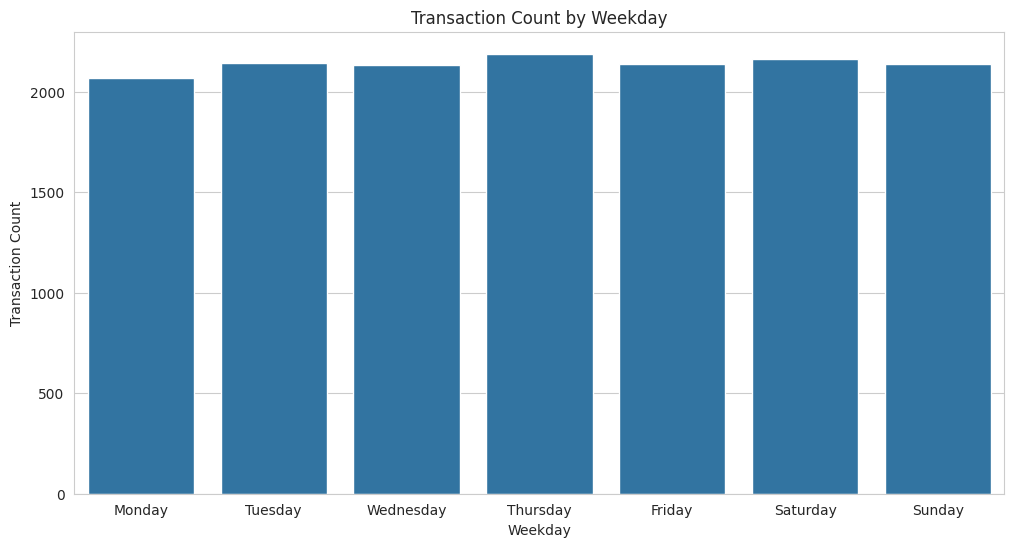

In [25]:
sns.barplot(
    data=weekday_summary,
    x="Weekday",
    y="TransactionCount"
)

plt.title("Transaction Count by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Transaction Count")

plt.show()

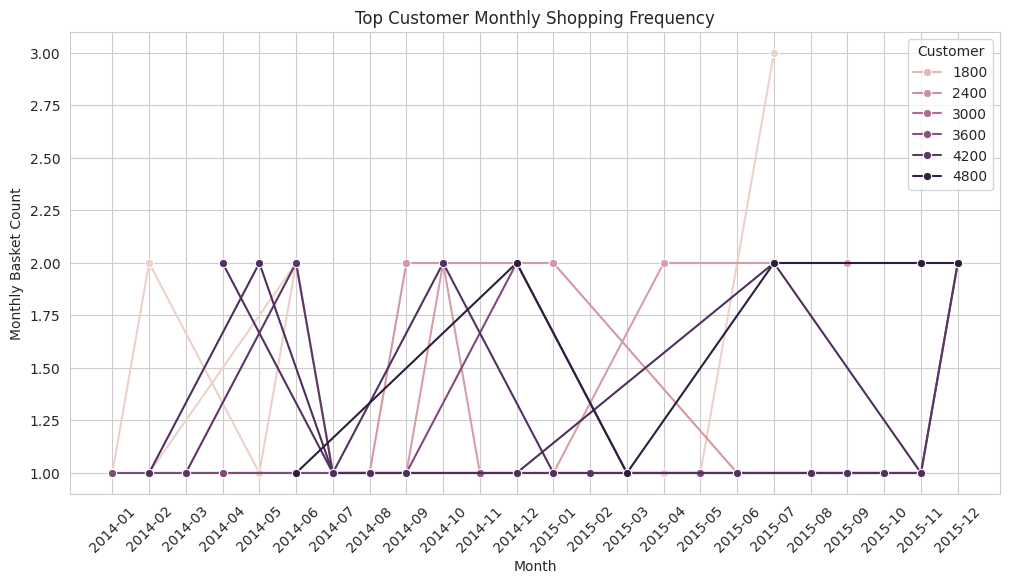

In [26]:
sns.lineplot(
    data=monthly_frequency,
    x="YearMonth",
    y="MonthlyBasketCount",
    hue="Member_number",
    marker="o"
)

plt.title("Top Customer Monthly Shopping Frequency")
plt.xlabel("Month")
plt.ylabel("Monthly Basket Count")

plt.xticks(rotation=45)

plt.legend(title="Customer")

plt.show()